In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv.zip to ecommerce_customer_data_custom_ratios.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile('ecommerce_customer_data_custom_ratios.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("File extracted successfully!")

File extracted successfully!


In [3]:
import os

os.listdir()

['.config',
 'ecommerce_customer_data_custom_ratios.csv',
 'ecommerce_customer_data_custom_ratios.csv.zip',
 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [7]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [8]:
df["Returns"] = df["Returns"].fillna(0)

df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


In [9]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

df.dtypes

,0
Customer ID,int64
Purchase Date,datetime64[ns]
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


In [10]:
df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.403076,43.940528,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.490517,15.350246,0.399622


In [11]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

Mean
Customer ID              25004.036240
Product Price              254.659512
Quantity                     2.998896
Total Purchase Amount     2725.370732
Customer Age                43.940528
Returns                      0.403076
Age                         43.940528
Churn                        0.199496
dtype: float64

Median
Customer ID              25018.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2724.0
Customer Age                44.0
Returns                      0.0
Age                         44.0
Churn                        0.0
dtype: float64

Mode
Customer ID                            36437
Purchase Date            2022-05-08 12:58:55
Product Category                    Clothing
Product Price                          100.0
Quantity                                 1.0
Total Purchase Amount                 2786.0
Payment Method                   Credit Card
Customer Age                            58.0
Returns                

In [14]:
customer_segment = df.groupby("Customer ID").agg({
    "Total Purchase Amount":"sum",
    "Quantity":"sum"
}).reset_index()

customer_segment.head()

,Customer ID,Total Purchase Amount,Quantity
0,1,3491,5
1,2,7988,8
2,3,22587,23
3,4,8715,9
4,5,12524,33


In [15]:
customer_segment["Segment"] = pd.qcut(
    customer_segment["Total Purchase Amount"],
    q=3,
    labels=["Low Value","Medium Value","High Value"]
)

customer_segment["Segment"].value_counts()

,count
Segment,
Low Value,16560
High Value,16557
Medium Value,16556


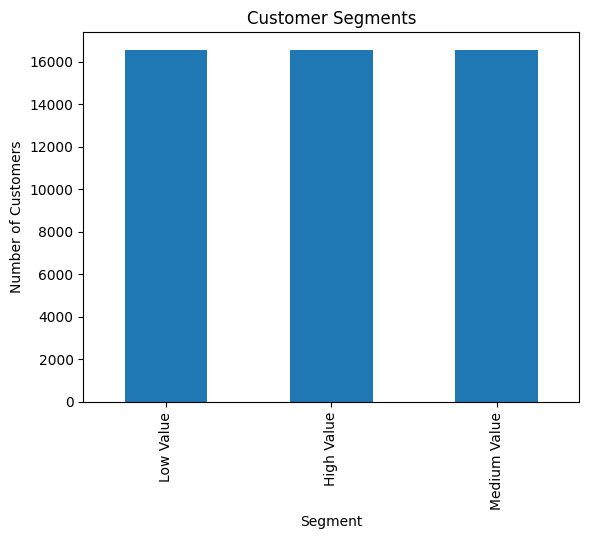

In [16]:
import matplotlib.pyplot as plt

customer_segment["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

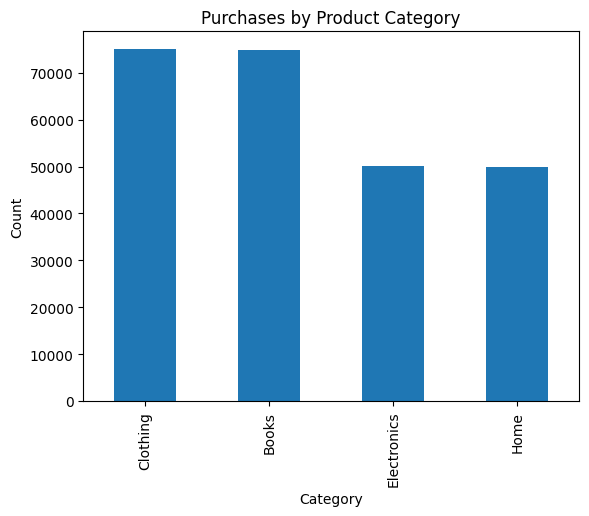

In [17]:
df["Product Category"].value_counts().plot(kind="bar")

plt.title("Purchases by Product Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

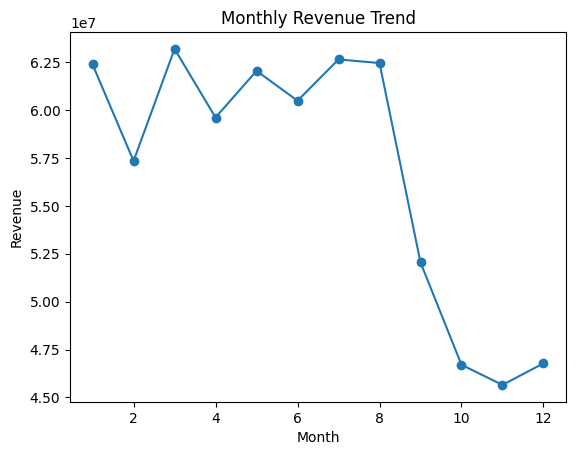

In [18]:
monthly_sales = df.groupby("Month")["Total Purchase Amount"].sum()

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

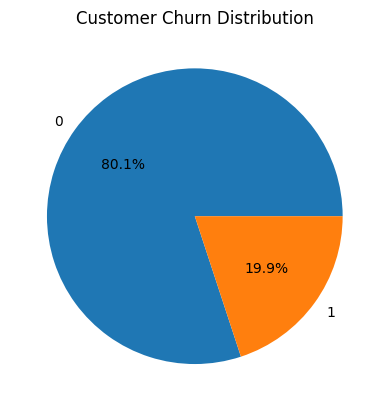

In [19]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

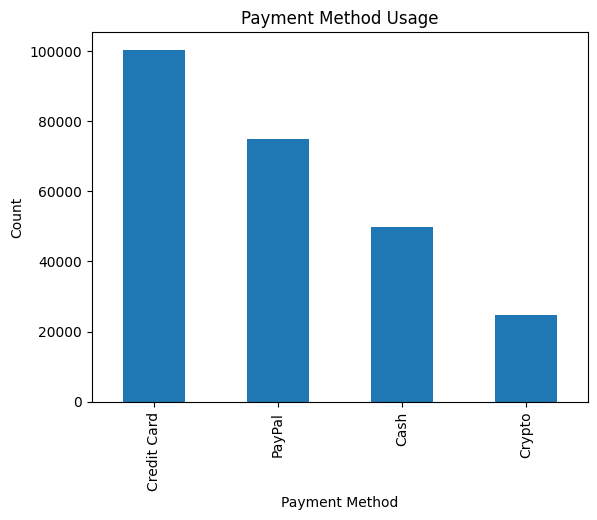

In [20]:
df["Payment Method"].value_counts().plot(kind="bar")

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

In [21]:
df.groupby("Product Category")["Total Purchase Amount"].sum().sort_values(ascending=False)

,Total Purchase Amount
Product Category,
Books,204939601
Clothing,204532405
Electronics,136599467
Home,135271210


In [22]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
0,80.0504
1,19.9496
